In [1]:
%matplotlib inline
import os
import re
import itertools
from itertools import combinations
import glob
import pickle
import argparse
import gzip

#import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import multiprocess as mp
import numpy as np
import pandas as pd
import bioframe as bf
from matplotlib import gridspec
from matplotlib.gridspec import GridSpec
import matplotlib.colors as colors
from matplotlib.colors import ListedColormap
from collections import OrderedDict
import plotly.express as px
import plotly.graph_objects as go
from matplotlib.cm import ScalarMappable
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt

import timeit

In [13]:
Lamina = pd.DataFrame({
    "stage": ["ES", "DE", "HB", "iHep", "mHep"],
    "LaminA": [11134, 12740, 106062, 86360, 129921],
    "LaminC": [24539, 53313, 92577, 82765, 103446],
    "LaminA+C": [35673, 66059, 198639, 169133, 233367],
    "Actin_LaminA": [227952, 267543, 191972, 133702, 119829],
    "LaminAC_LBR": [172323, 234300, 189069, 170890, 194712],
    "LBR": [336310, 367047, 76000, 37053, 79000],
    "Actin_LBR": [162930, 166090, 136167, 140843, 114307],
    "LaminB2": [33630, 8625, 700, 1, 25],
    "Actin_LaminB2": [43892, 63570, 36077, 79510, 99010]
})

Lamina = Lamina.set_index("stage")
Lamina

,LaminA,LaminC,LaminA+C,Actin_LaminA,LaminAC_LBR,LBR,Actin_LBR,LaminB2,Actin_LaminB2
stage,,,,,,,,,
ES,11134,24539,35673,227952,172323,336310,162930,33630,43892
DE,12740,53313,66059,267543,234300,367047,166090,8625,63570
HB,106062,92577,198639,191972,189069,76000,136167,700,36077
iHep,86360,82765,169133,133702,170890,37053,140843,1,79510
mHep,129921,103446,233367,119829,194712,79000,114307,25,99010


In [14]:
# Normalize each protein by its own Actin loading control
Lamina["LaminA_norm_raw"] = Lamina["LaminA"] / Lamina["Actin_LaminA"]
Lamina["LaminC_norm_raw"] = Lamina["LaminC"] / Lamina["Actin_LaminA"]

Lamina["LBR_norm_raw"] = Lamina["LBR"] / Lamina["Actin_LBR"]
Lamina["LaminB2_norm_raw"] = Lamina["LaminB2"] / Lamina["Actin_LaminB2"]

# Scale each normalized value by its own maximum
Lamina["LaminA normalized to Actin"] = Lamina["LaminA_norm_raw"] / Lamina["LaminA_norm_raw"].max()
Lamina["LaminC normalized to Actin"] = Lamina["LaminC_norm_raw"] /Lamina["LaminA_norm_raw"].max()

Lamina["LBR normalized to Actin"] = Lamina["LBR_norm_raw"] / Lamina["LBR_norm_raw"].max()
Lamina["LaminB2 normalized to Actin"] = Lamina["LaminB2_norm_raw"] / Lamina["LaminB2_norm_raw"].max()

Lamina

,LaminA,LaminC,LaminA+C,Actin_LaminA,LaminAC_LBR,LBR,Actin_LBR,LaminB2,Actin_LaminB2,LaminA_norm_raw,LaminC_norm_raw,LBR_norm_raw,LaminB2_norm_raw,LaminA normalized to Actin,LaminC normalized to Actin,LBR normalized to Actin,LaminB2 normalized to Actin
stage,,,,,,,,,,,,,,,,,
ES,11134,24539,35673,227952,172323,336310,162930,33630,43892,0.048844,0.107650,2.064138,0.766199,0.045050,0.099288,0.934029,1.000000
DE,12740,53313,66059,267543,234300,367047,166090,8625,63570,0.047619,0.199269,2.209928,0.135677,0.043920,0.183790,1.000000,0.177078
HB,106062,92577,198639,191972,189069,76000,136167,700,36077,0.552487,0.482242,0.558138,0.019403,0.509571,0.444783,0.252559,0.025324
iHep,86360,82765,169133,133702,170890,37053,140843,1,79510,0.645914,0.619026,0.263080,0.000013,0.595741,0.570941,0.119045,0.000016
mHep,129921,103446,233367,119829,194712,79000,114307,25,99010,1.084220,0.863280,0.691121,0.000252,1.000000,0.796222,0.312735,0.000330


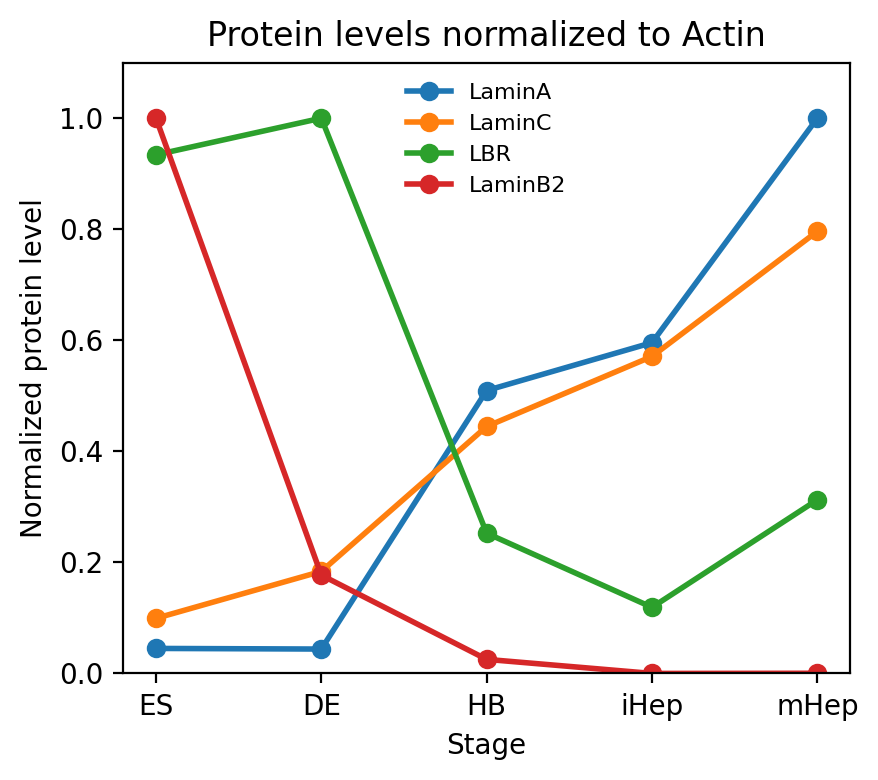

In [17]:
plot_cols = [
    "LaminA normalized to Actin",
    "LaminC normalized to Actin",
    "LBR normalized to Actin",
    "LaminB2 normalized to Actin"
]

stage_order = ["ES", "DE", "HB", "iHep", "mHep"]

plot_df = Lamina.loc[stage_order].copy()

plt.figure(figsize=(4.5, 4), dpi=200)

for col in plot_cols:
    plt.plot(
        plot_df.index,
        plot_df[col],
        marker="o",
        linewidth=2,
        label=col.replace(" normalized to Actin", "")
    )

plt.xlabel("Stage")
plt.ylabel("Normalized protein level")
plt.ylim(0, 1.1)
plt.title("Protein levels normalized to Actin")
plt.legend(frameon=False, fontsize=8)
plt.tight_layout()

plt.savefig("/home/xiangru.huo-umw/scHiC/scripts/plot/Lamin_LBR_LaminB2_normalized_lineplot.pdf", bbox_inches="tight")
plt.show()

In [ ]:
#plot the compartment strength + insulation

In [3]:
HiCfeature = pd.DataFrame({
    "stage": ["DE", "DE+1d", "DE+2d","DE+3d","DE+4d","DE+5d","DE+6d","DE+7d","HB"],
    "Comp": [0, 0.262948936, 0.717076438, 0.997539203, 1.187469992,1.584854345,1.536491972,1.169054756,1.169054756],
    "Insulation": [0, -0.083660655, 0.47280849, 0.234154292, 0.247611745,0.454468257,0.416408193,0.682613514,1],
    "Dots": [0, 0.226415094, 0.698113208, 0.188679245, 0.056603774, 0.41509434, 0.509433962, 0.773584906, 1],
    "Comp_raw": [3.33407509546003, 3.782946860394271, 4.55817347429062, 5.036942538720786, 5.361167347558907, 6.039529535482768, 5.956971666869024, 5.329731283427393, 5.041143286837534],
    "Insulation_raw": [0.33532291771478984, 0.3286266083474873, 0.37316713379992617, 0.3540649365183497, 0.3551420888357088, 0.3716991573075422, 0.36865277951048697, 0.38996020506118345, 0.4153642386218773],
    "Dots_raw": [2.400075671975632,2.506754466152261,2.737063208296767,2.4775674395889538,2.405647660353247,2.586641661360211,2.6336925206531885,2.754687322764171,2.8720982712415215],
})

#dots in DE: 2.5116389447081966,3.228771819577838
#dots in HB: 3.047813598493587, 3.865067070209121

#insulation score in DE:0.39516803335762696, 0.41276776773603274
#insulation score in HB: 0.41594107750947573,0.4710782690150622

HiCfeature = HiCfeature.set_index("stage")
HiCfeature

,Comp,Insulation,Dots,Comp_raw,Insulation_raw,Dots_raw
stage,,,,,,
DE,0.000000,0.000000,0.000000,3.334075,0.335323,2.400076
DE+1d,0.262949,-0.083661,0.226415,3.782947,0.328627,2.506754
DE+2d,0.717076,0.472808,0.698113,4.558173,0.373167,2.737063
DE+3d,0.997539,0.234154,0.188679,5.036943,0.354065,2.477567
DE+4d,1.187470,0.247612,0.056604,5.361167,0.355142,2.405648
DE+5d,1.584854,0.454468,0.415094,6.039530,0.371699,2.586642
DE+6d,1.536492,0.416408,0.509434,5.956972,0.368653,2.633693
DE+7d,1.169055,0.682614,0.773585,5.329731,0.389960,2.754687
HB,1.169055,1.000000,1.000000,5.041143,0.415364,2.872098


/tmp/ipykernel_3829393/2658152322.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False, fontsize=8)


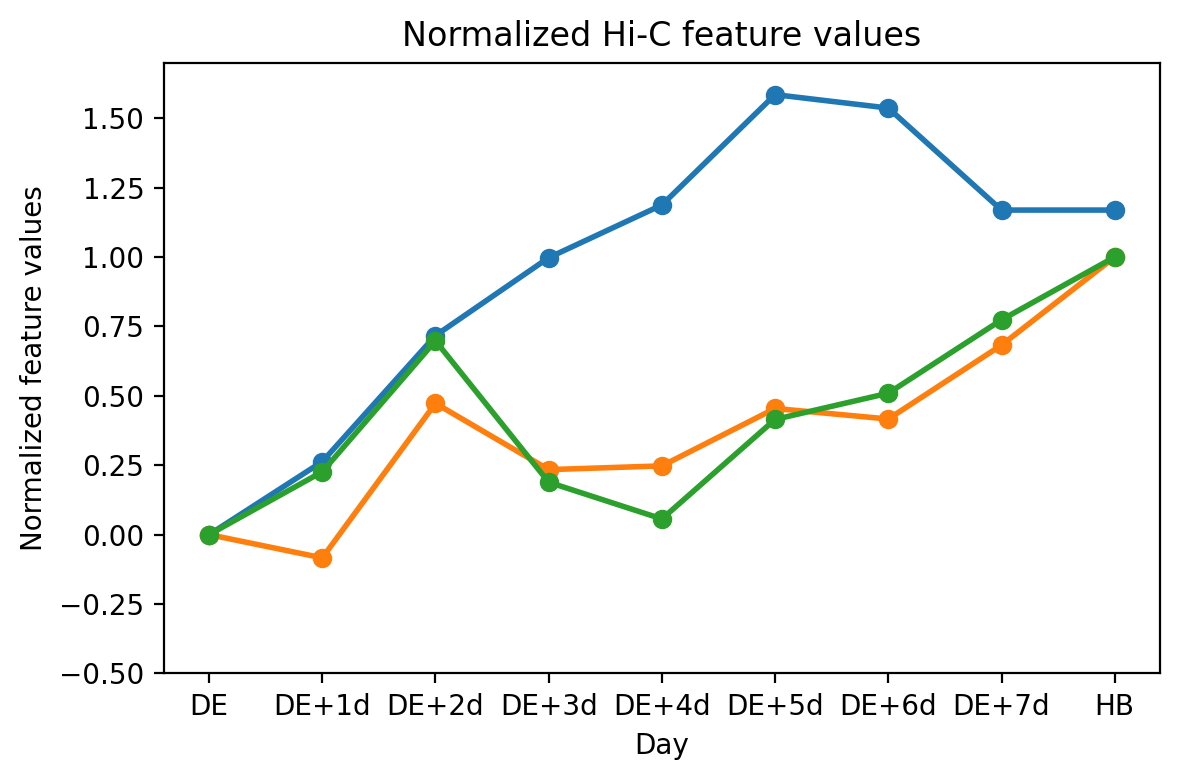

In [7]:
plot_cols = [
    "Comp",
    "Insulation",
    "Dots"
]

stage_order = ["DE", "DE+1d", "DE+2d","DE+3d","DE+4d","DE+5d","DE+6d","DE+7d","HB"]

plot_df = HiCfeature.loc[stage_order].copy()

plt.figure(figsize=(6, 4), dpi=200)

for col in plot_cols:
    plt.plot(
        plot_df.index,
        plot_df[col],
        marker="o",
        linewidth=2,
    )

plt.xlabel("Day")
plt.ylabel("Normalized feature values")
plt.ylim(-0.5, 1.7)
plt.title("Normalized Hi-C feature values")
plt.legend(frameon=False, fontsize=8)
plt.tight_layout()

plt.savefig("/home/xiangru.huo-umw/scHiC/scripts/plot/HiC_normalized_feature_8days_lineplot.pdf", bbox_inches="tight")
plt.show()

/tmp/ipykernel_1241734/2660731984.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False, fontsize=8)


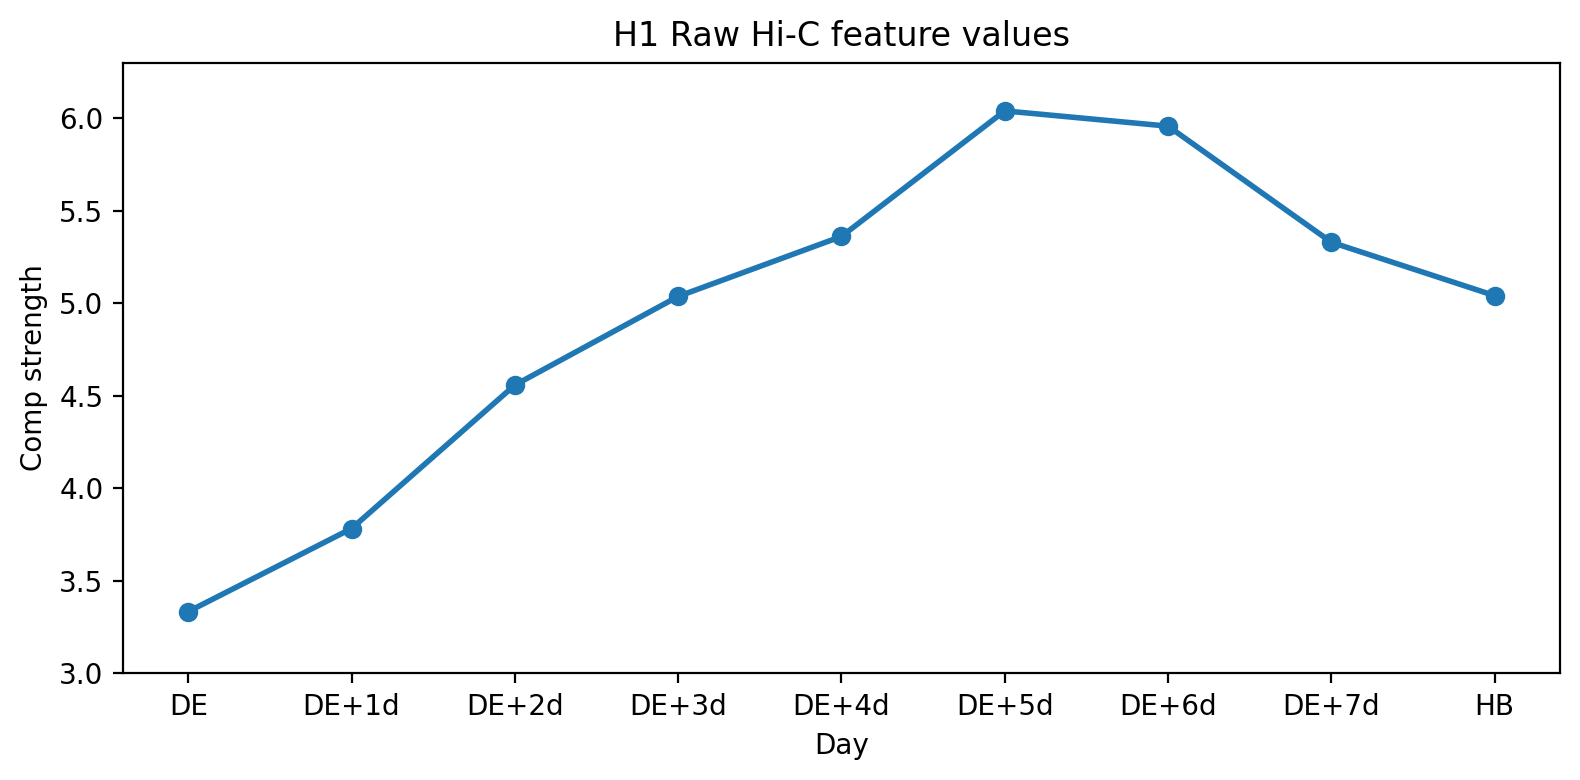

In [12]:
plot_cols = [
    "Comp_raw"
]

stage_order = ["DE", "DE+1d", "DE+2d","DE+3d","DE+4d","DE+5d","DE+6d","DE+7d","HB"]

plot_df = HiCfeature.loc[stage_order].copy()

plt.figure(figsize=(8, 4), dpi=200)

for col in plot_cols:
    plt.plot(
        plot_df.index,
        plot_df[col],
        marker="o",
        linewidth=2,
    )

plt.xlabel("Day")
plt.ylabel("Comp strength")
plt.ylim(3, 6.3)
plt.title("H1 Raw Hi-C feature values")
plt.legend(frameon=False, fontsize=8)
plt.tight_layout()

plt.savefig("/home/xiangru.huo-umw/scHiC/scripts/plot/HiC_comp_raw_feature_8days_lineplot.pdf", bbox_inches="tight")
plt.show()

In [14]:
H9_HiCfeature = pd.DataFrame({
    "stage": ["H9-DE", "DE+1d", "DE+2d","DE+3d","DE+4d","DE+5d","DE+6d","DE+7d","H9-HB"],
    "Comp_raw": [3.7982522682459976, 3.5525792543140766, 3.4601113486735904, 4.596038229464847, 5.46157104283266, 5.763096234032524, 5.664350507284335, 5.340207746700472, 5.4754133737557105],
    "Insulation_raw": [0.42294701657143674, 0.32585777708202923, 0.2890947216691714, 0.34205313869060816, 0.37354196690866426, 0.3938303757773106, 0.3909360074099233, 0.3638604704978593, 0.3671496495455713],
    "Dots_raw": [2.933064822526774,2.348474489814296,2.247949145996581,2.3477964851937574,2.6053588719406644,2.711670546682074,2.6762029020022373,2.6172423200257953,2.6776890777632523],
})

# normalize each feature: start point = 0, end point = 1
for col in ["Comp_raw", "Insulation_raw", "Dots_raw"]:
    H9_HiCfeature[col.replace("_raw", "")] = (
        H9_HiCfeature[col] - H9_HiCfeature[col].iloc[0]
    ) / (
        H9_HiCfeature[col].iloc[-1] - H9_HiCfeature[col].iloc[0]
    )

H9_HiCfeature = H9_HiCfeature.set_index("stage")
H9_HiCfeature

,Comp_raw,Insulation_raw,Dots_raw,Comp,Insulation,Dots
stage,,,,,,
H9-DE,3.798252,0.422947,2.933065,0.000000,-0.000000,-0.000000
DE+1d,3.552579,0.325858,2.348474,-0.146481,1.740033,2.289138
DE+2d,3.460111,0.289095,2.247949,-0.201615,2.398900,2.682775
DE+3d,4.596038,0.342053,2.347796,0.475676,1.449779,2.291793
DE+4d,5.461571,0.373542,2.605359,0.991747,0.885437,1.283231
DE+5d,5.763096,0.393830,2.711671,1.171530,0.521828,0.866935
DE+6d,5.664351,0.390936,2.676203,1.112653,0.573701,1.005820
DE+7d,5.340208,0.363860,2.617242,0.919384,1.058949,1.236697
H9-HB,5.475413,0.367150,2.677689,1.000000,1.000000,1.000000


/tmp/ipykernel_1241734/1456172158.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False, fontsize=8)


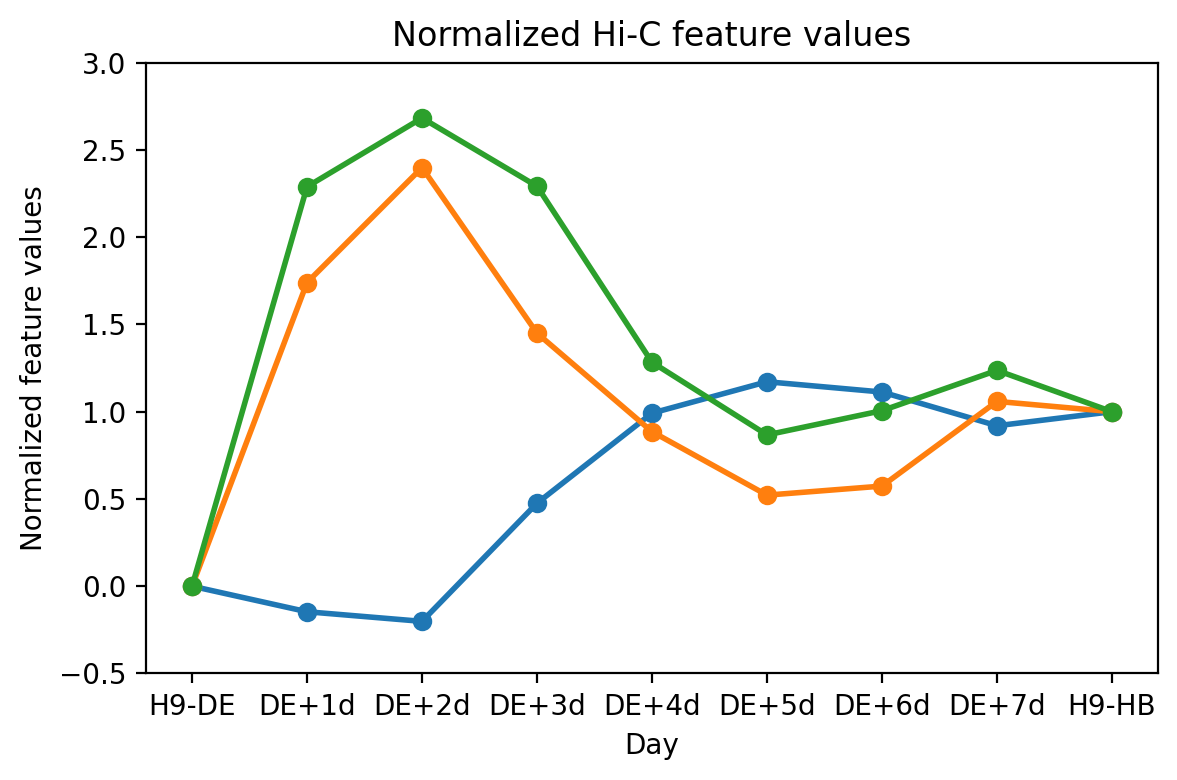

In [16]:
plot_cols = [
    "Comp",
    "Insulation",
    "Dots"
]

stage_order = ["H9-DE", "DE+1d", "DE+2d","DE+3d","DE+4d","DE+5d","DE+6d","DE+7d","H9-HB"]

plot_df = H9_HiCfeature.loc[stage_order].copy()

plt.figure(figsize=(6, 4), dpi=200)

for col in plot_cols:
    plt.plot(
        plot_df.index,
        plot_df[col],
        marker="o",
        linewidth=2,
    )

plt.xlabel("Day")
plt.ylabel("Normalized feature values")
plt.ylim(-0.5, 3)
plt.title("Normalized Hi-C feature values")
plt.legend(frameon=False, fontsize=8)
plt.tight_layout()

plt.savefig("/home/xiangru.huo-umw/scHiC/scripts/plot/H9_HiC_normalized_feature_8days_lineplot.pdf", bbox_inches="tight")
plt.show()

/tmp/ipykernel_1241734/1355070059.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False, fontsize=8)


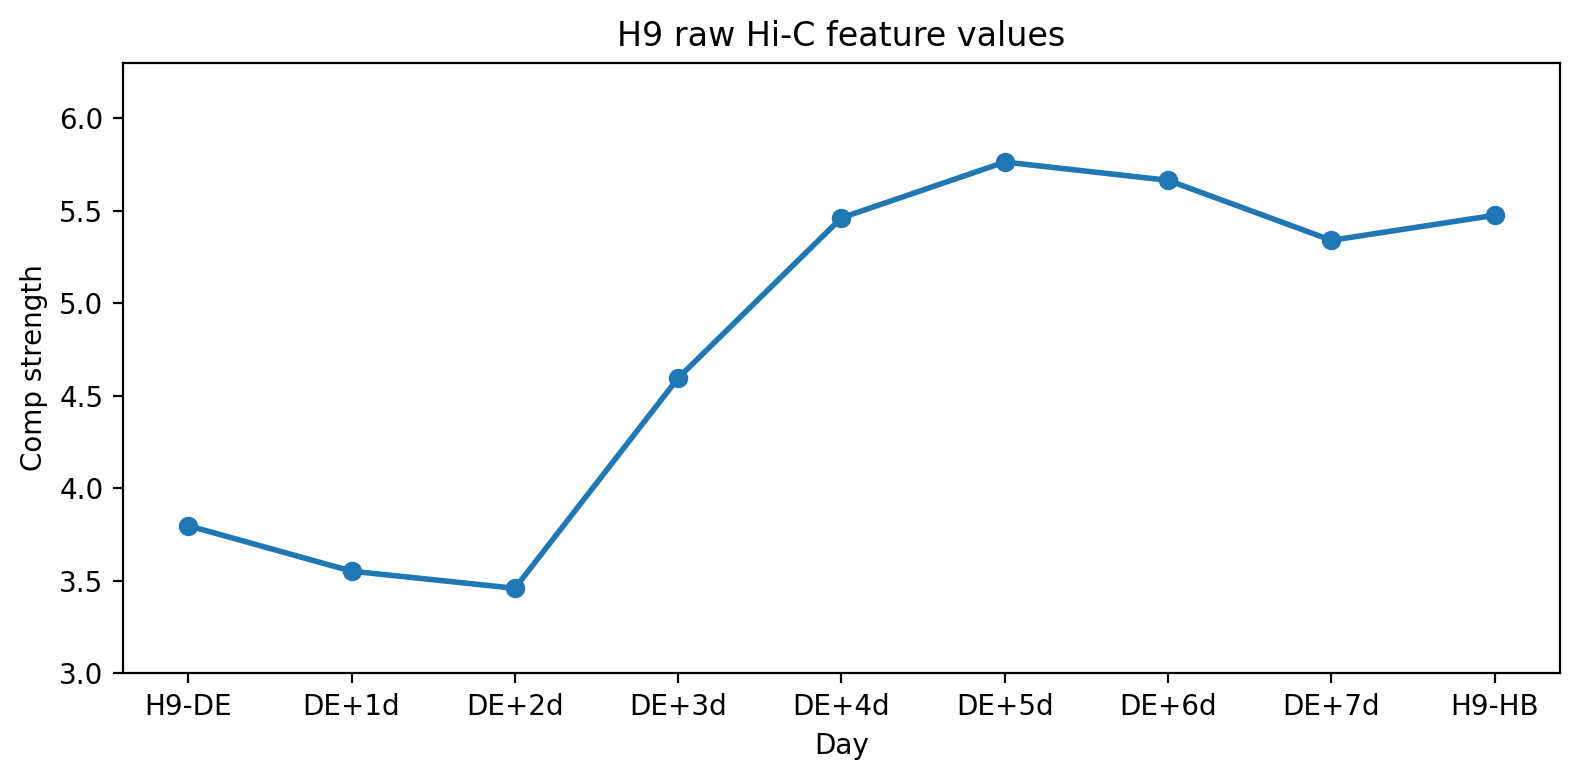

In [13]:
plot_cols = [
    "Comp_raw"
]

stage_order = ["H9-DE", "DE+1d", "DE+2d","DE+3d","DE+4d","DE+5d","DE+6d","DE+7d","H9-HB"]

plot_df = H9_HiCfeature.loc[stage_order].copy()

plt.figure(figsize=(8, 4), dpi=200)

for col in plot_cols:
    plt.plot(
        plot_df.index,
        plot_df[col],
        marker="o",
        linewidth=2,
    )

plt.xlabel("Day")
plt.ylabel("Comp strength")
plt.ylim(3, 6.3)
plt.title("H9 raw Hi-C feature values")
plt.legend(frameon=False, fontsize=8)
plt.tight_layout()

plt.savefig("/home/xiangru.huo-umw/scHiC/scripts/plot/H9_HiC_comp_raw_feature_8days_lineplot.pdf", bbox_inches="tight")
plt.show()